# Compare runs

Loads a user-specified selection of runs and produces one comparison plot per metric.
Each figure puts runs on the x-axis with bars grouped by agent, so you compare the agents within each run (and across runs).

In [1]:
# --- runs to compare (edit this list) ---
RUNS = [
    "alphabeta_vs_gemma_standard_match",
    "alphabeta_vs_gemma_symbols_match",
    "alphabeta_vs_gemma_symbols_prompt_match",
    "alphabeta_vs_gemma_symbols_full_prompt_match",
]

# Optional display names shown on the plots (raw run name is used as a fallback).
RUN_LABELS = {
    "alphabeta_vs_gemma_standard_match": "standard",
    "alphabeta_vs_gemma_symbols_match": "Experiment 1",
    "alphabeta_vs_gemma_symbols_prompt_match": "Experiment 2",
    "alphabeta_vs_gemma_symbols_full_prompt_match": "Experiment 3",
}

RUNS_DIR = "runs"

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from evaluation.metrics import collect_move_tokens, score_results
from evaluation.runner import load_results, result_from_dict

RUNS_DIR = Path(RUNS_DIR)


def run_label(run: str) -> str:
    """Display name for a run, falling back to the raw name."""
    return RUN_LABELS.get(run, run)


# Label order matching RUNS, for consistent x-axis / facet ordering.
RUN_ORDER = [run_label(r) for r in RUNS]

c:\Users\61417\Documents\misc_projects\LLMs_and_tictactoe\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def load_run(run: str):
    """Return (per-agent stats rows, raw ResultSpec list) for one run."""
    results = [result_from_dict(d) for d in load_results(RUNS_DIR / run / "games.jsonl")]
    stats = score_results(results)
    rows = [{**s.to_dict(), "run": run_label(run)} for s in stats.values()]
    return rows, results


stat_rows, move_token_rows, game_token_rows = [], [], []
for run in RUNS:
    rows, results = load_run(run)
    stat_rows.extend(rows)

    # one row per move (output-token distribution)
    for agent, vals in collect_move_tokens(results).items():
        move_token_rows.extend(
            {"run": run_label(run), "agent_name": agent, "output_tokens": v} for v in vals
        )

    # one row per (game, agent) summing that game's output tokens
    for r in results:
        if not r.llm_interactions or not r.agent_names:
            continue
        for pidx, moves in r.llm_interactions.items():
            if not moves:
                continue
            total = sum(m.get("total_tokens", {}).get("output", 0) for m in moves)
            game_token_rows.append(
                {"run": run_label(run), "agent_name": r.agent_names[int(pidx)], "total_tokens": total}
            )

stats_df = pd.DataFrame(stat_rows)
move_token_df = pd.DataFrame(move_token_rows)
game_token_df = pd.DataFrame(game_token_rows)
stats_df

,agent_name,games,wins,draws,losses,invalid_moves,optimal_actions,total_actions,win_rate,draw_rate,loss_rate,invalid_rate,optimality_rate,run
0,alphabeta,30,0,30,0,0,135,135,0.000000,1.000000,0.000000,0.000000,1.000000,standard
1,gemma4,30,0,30,0,0,135,135,0.000000,1.000000,0.000000,0.000000,1.000000,standard
2,alphabeta,30,29,1,0,0,66,66,0.966667,0.033333,0.000000,0.000000,1.000000,Experiment 1
3,gemma4,30,0,1,29,27,49,78,0.000000,0.033333,0.966667,0.900000,0.628205,Experiment 1
4,alphabeta,30,27,3,0,0,93,93,0.900000,0.100000,0.000000,0.000000,1.000000,Experiment 2
5,gemma4,30,0,3,27,25,75,103,0.000000,0.100000,0.900000,0.833333,0.728155,Experiment 2
6,alphabeta,30,0,30,0,0,135,135,0.000000,1.000000,0.000000,0.000000,1.000000,Experiment 3
7,gemma4,30,0,30,0,0,135,135,0.000000,1.000000,0.000000,0.000000,1.000000,Experiment 3


In [4]:
def plot_by_run(df, metric, title, ylim=None):
    """Grouped bar chart: x = run, bars grouped by agent, y = metric."""
    if df.empty or metric not in df:
        print(f"No data for {metric!r}")
        return
    fig, ax = plt.subplots(figsize=(max(8, 2.2 * len(RUNS)), 5))
    sns.barplot(data=df, x="run", y=metric, hue="agent_name", order=RUN_ORDER, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=15)
    ax.legend(title="agent", fontsize=8)
    fig.tight_layout()
    plt.show()

## Optimality

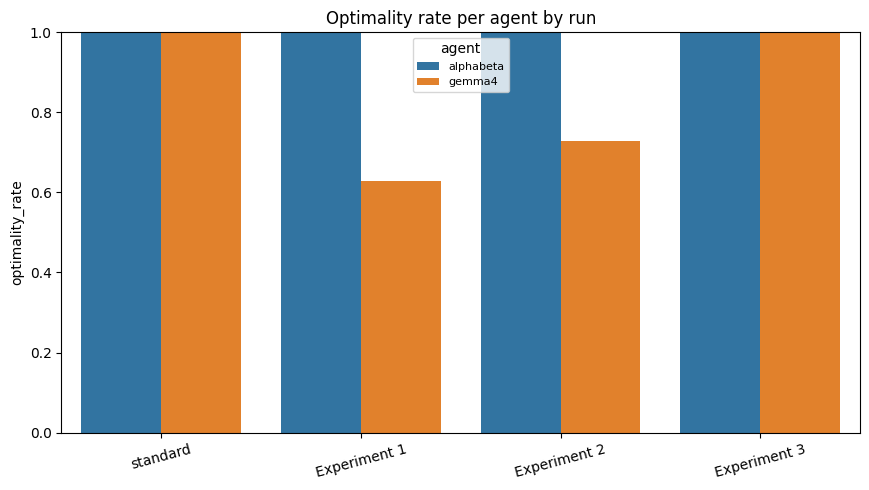

In [5]:
plot_by_run(stats_df, "optimality_rate", "Optimality rate per agent by run", ylim=(0, 1))

## Outcome rates

One separate plot per outcome.

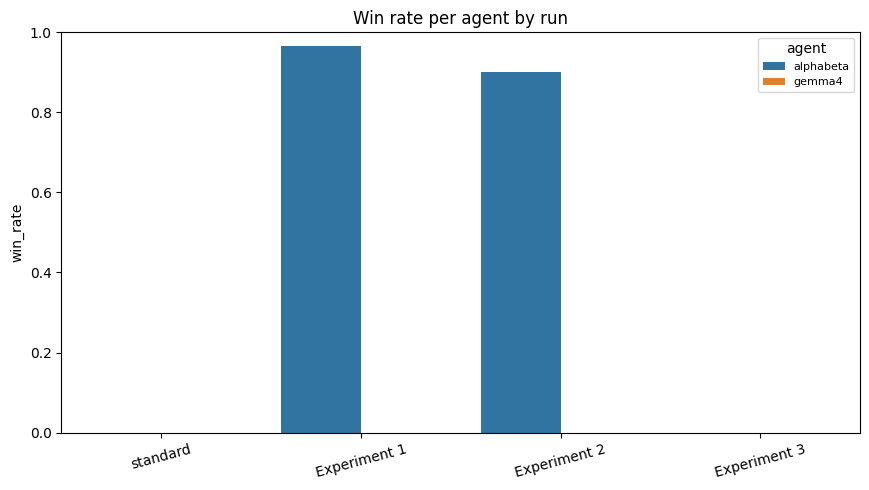

In [6]:
plot_by_run(stats_df, "win_rate", "Win rate per agent by run", ylim=(0, 1))

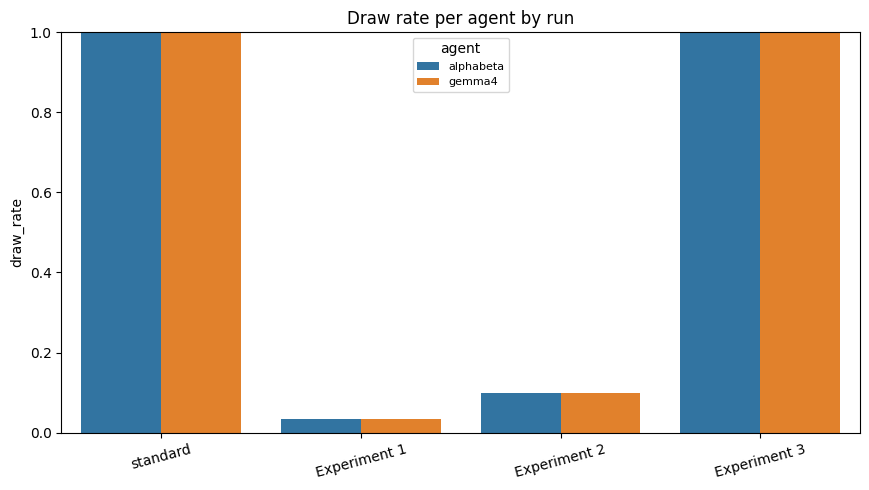

In [7]:
plot_by_run(stats_df, "draw_rate", "Draw rate per agent by run", ylim=(0, 1))

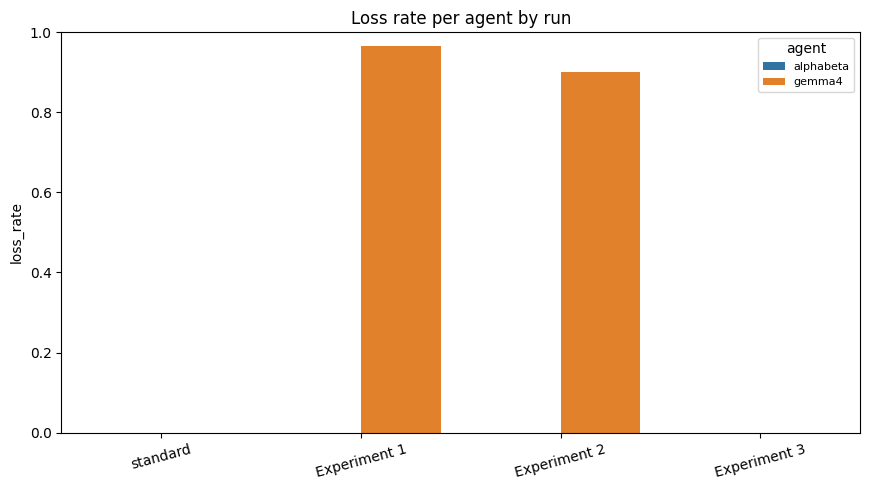

In [8]:
plot_by_run(stats_df, "loss_rate", "Loss rate per agent by run", ylim=(0, 1))

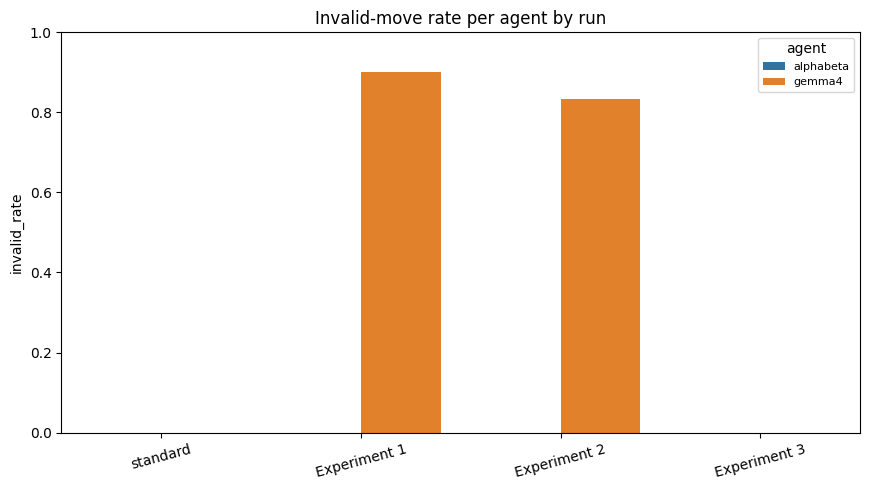

In [9]:
plot_by_run(stats_df, "invalid_rate", "Invalid-move rate per agent by run", ylim=(0, 1))

## Token usage

Box plots of the full distribution. Only agents with LLM interactions appear
(e.g. alphabeta is omitted).

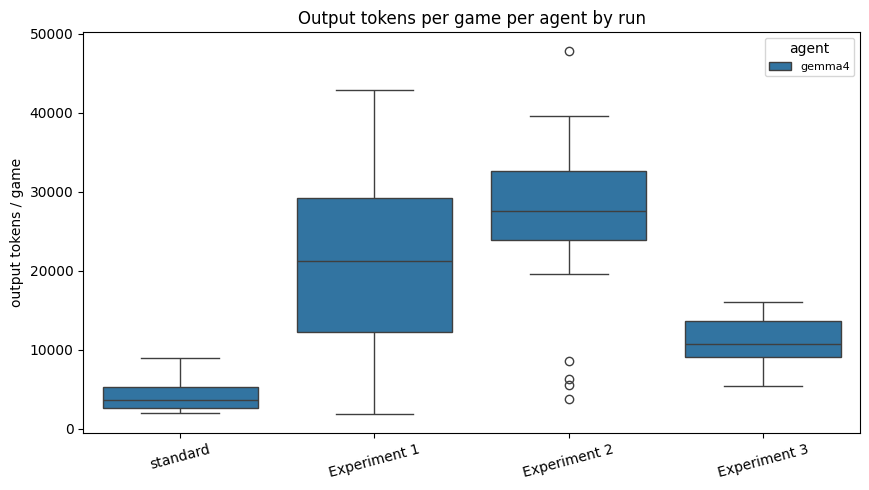

In [10]:
def box_by_run(df, metric, title, ylabel=None):
    """Box plot: x = run, boxes grouped by agent, y = metric distribution."""
    if df.empty or metric not in df:
        print(f"No data for {metric!r}")
        return
    fig, ax = plt.subplots(figsize=(max(8, 2.2 * len(RUNS)), 5))
    sns.boxplot(data=df, x="run", y=metric, hue="agent_name", order=RUN_ORDER, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel or metric)
    ax.tick_params(axis="x", rotation=15)
    ax.legend(title="agent", fontsize=8)
    fig.tight_layout()
    plt.show()


box_by_run(game_token_df, "total_tokens", "Output tokens per game per agent by run", "output tokens / game")

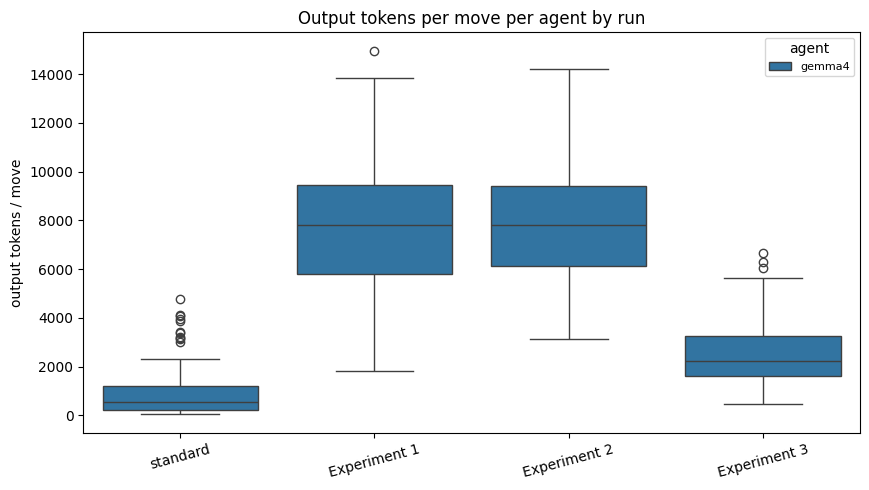

In [11]:
box_by_run(move_token_df, "output_tokens", "Output tokens per move per agent by run", "output tokens / move")

## Game length, first-mover, and invalid-move analysis

One row per (game, agent): the outcome from that agent's point of view, the
game length (number of moves, including a final invalid move), whether the agent
started, and — for invalid losses — the turn the invalid move was made on.

In [12]:
OUTCOME_ORDER = ["win", "draw", "loss", "invalid"]


def game_records(run, results):
    """One row per (game, agent) from that agent's point of view."""
    rows = []
    for r in results:
        length = len(r.actions)
        first = r.player[0] if r.player else None
        for idx, name in enumerate(r.agent_names):
            if r.winner == idx:
                outcome = "win"
            elif r.winner is None:
                outcome = "draw"
            elif r.invalid and r.player and r.player[-1] == idx:
                outcome = "invalid"
            else:
                outcome = "loss"
            rows.append({
                "run": run_label(run),
                "agent_name": name,
                "outcome": outcome,
                "game_length": length,
                "start": "first" if idx == first else "second",
                # invalid move is the final move, so its turn == game length
                "invalid_turn": length if outcome == "invalid" else None,
            })
    return rows


game_rows = []
for run in RUNS:
    _, results = load_run(run)
    game_rows.extend(game_records(run, results))

games_df = pd.DataFrame(game_rows)
games_df.head()

,run,agent_name,outcome,game_length,start,invalid_turn
0,standard,alphabeta,draw,9,first,NaN
1,standard,gemma4,draw,9,second,NaN
2,standard,gemma4,draw,9,first,NaN
3,standard,alphabeta,draw,9,second,NaN
4,standard,alphabeta,draw,9,first,NaN


### Game-length distribution by outcome

One figure per agent; within each, game lengths are split by outcome and faceted by run.

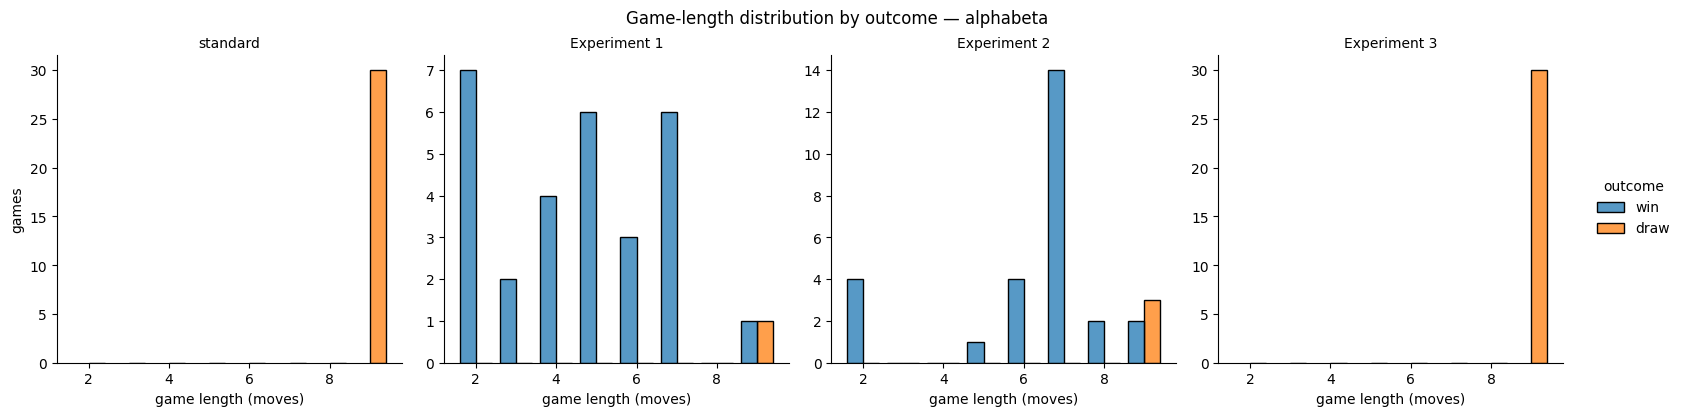

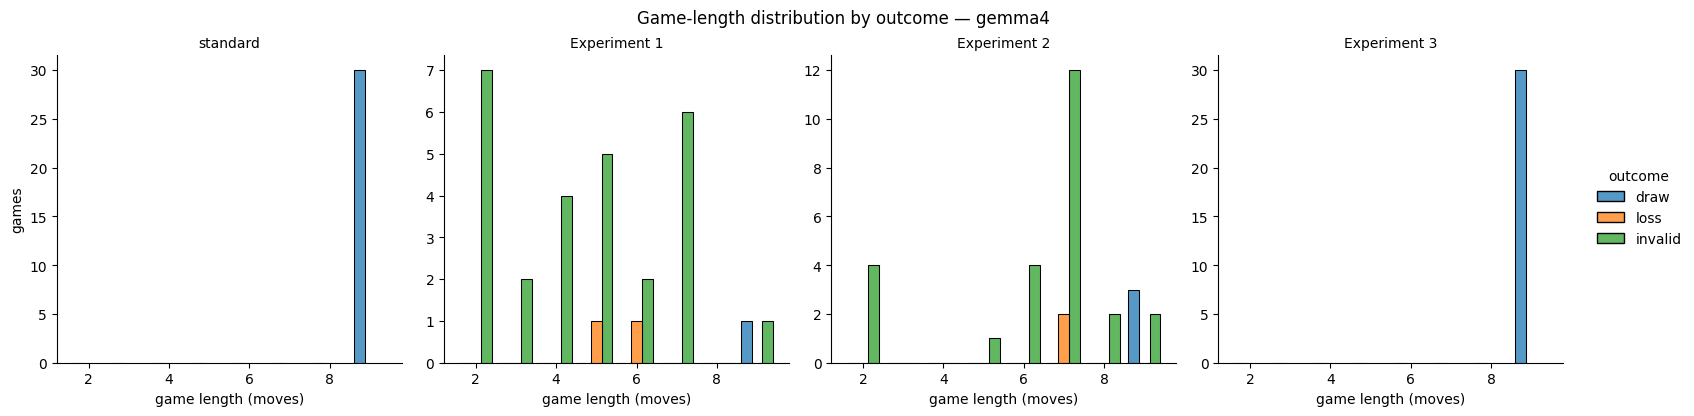

In [13]:
def plot_game_length_dist(df, agent):
    sub = df[df["agent_name"] == agent]
    if sub.empty:
        print(f"No data for {agent!r}")
        return
    present = [o for o in OUTCOME_ORDER if o in set(sub["outcome"])]
    g = sns.displot(
        sub, x="game_length", hue="outcome", col="run",
        hue_order=present, col_order=RUN_ORDER, multiple="dodge",
        discrete=True, shrink=0.8, height=4, facet_kws={"sharey": False},
    )
    g.figure.suptitle(f"Game-length distribution by outcome — {agent}", y=1.03)
    g.set_axis_labels("game length (moves)", "games")
    g.set_titles("{col_name}")
    plt.show()


for agent in sorted(games_df["agent_name"].unique()):
    plot_game_length_dist(games_df, agent)

### Performance by who moved first

Outcome composition (proportions) for games where the agent moved first vs second.

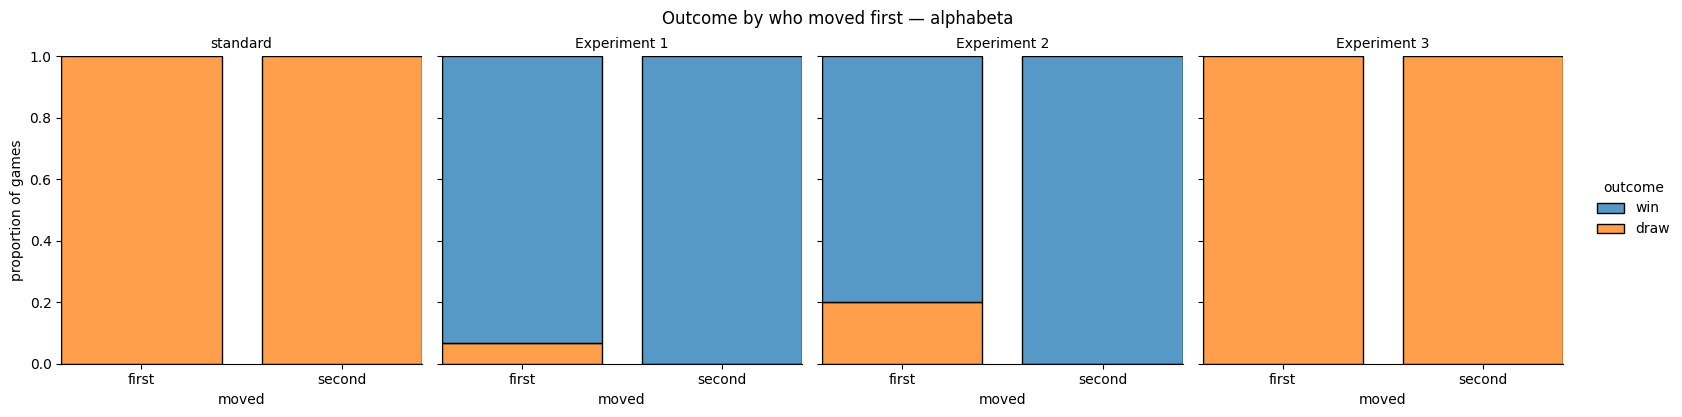

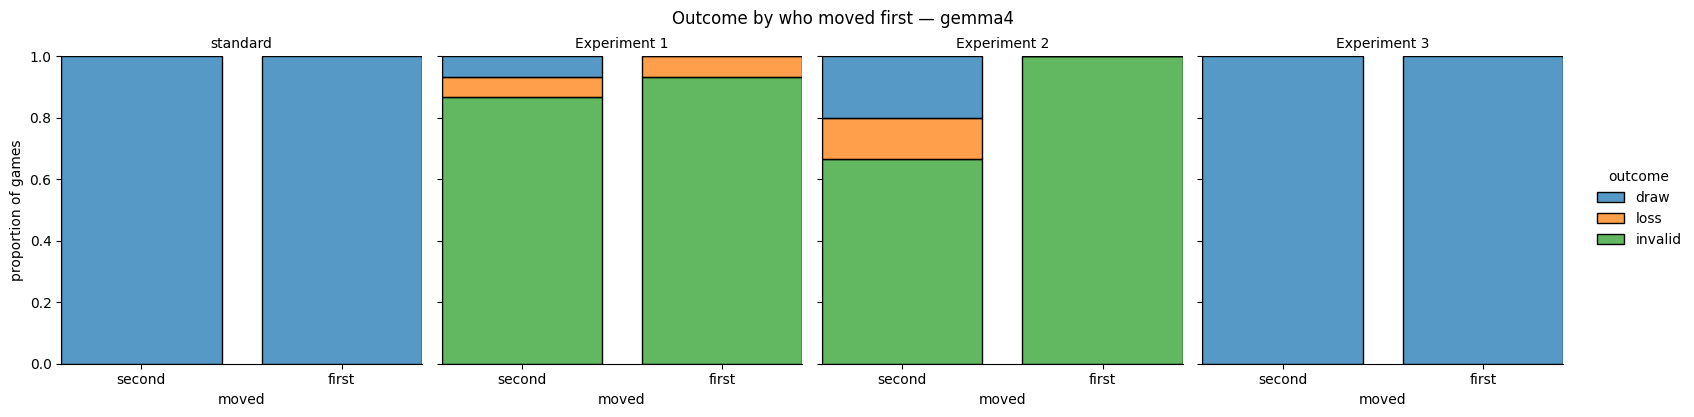

In [14]:
def plot_first_mover(df, agent):
    sub = df[df["agent_name"] == agent]
    if sub.empty:
        print(f"No data for {agent!r}")
        return
    present = [o for o in OUTCOME_ORDER if o in set(sub["outcome"])]
    g = sns.displot(
        sub, x="start", hue="outcome", col="run",
        hue_order=present, col_order=RUN_ORDER, multiple="fill",
        shrink=0.8, height=4,
    )
    g.figure.suptitle(f"Outcome by who moved first — {agent}", y=1.03)
    g.set_axis_labels("moved", "proportion of games")
    g.set_titles("{col_name}")
    plt.show()


for agent in sorted(games_df["agent_name"].unique()):
    plot_first_mover(games_df, agent)

### Turn at which invalid moves were made

For agents that made invalid moves, the turn number (total moves played, including
the invalid one) on which the invalid move happened.

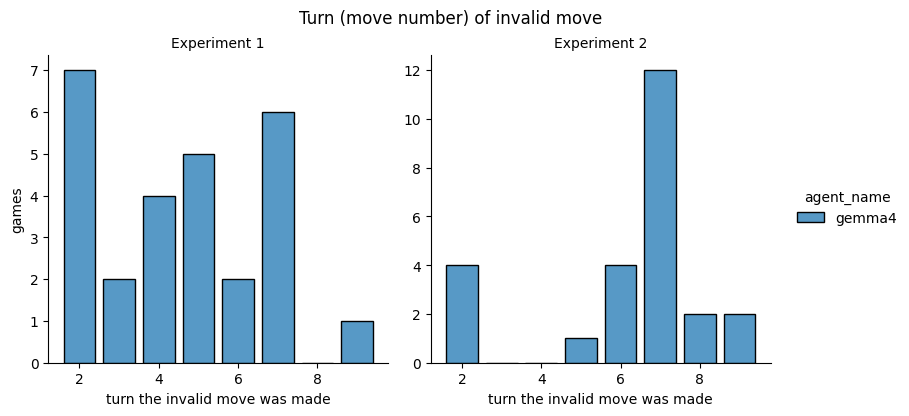

In [15]:
def plot_invalid_turns(df):
    sub = df[df["outcome"] == "invalid"]
    if sub.empty:
        print("No invalid moves recorded.")
        return
    runs_present = [r for r in RUN_ORDER if r in set(sub["run"])]
    g = sns.displot(
        sub, x="invalid_turn", hue="agent_name", col="run",
        col_order=runs_present, multiple="dodge", discrete=True,
        shrink=0.8, height=4, facet_kws={"sharey": False},
    )
    g.figure.suptitle("Turn (move number) of invalid move", y=1.03)
    g.set_axis_labels("turn the invalid move was made", "games")
    g.set_titles("{col_name}")
    plt.show()


plot_invalid_turns(games_df)